# Hydrometeor ID stats

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc, colors, ticker
import matplotlib.dates as mdates
from scipy.interpolate import interp2d, RectBivariateSpline
from scipy.stats import spearmanr
from datetime import datetime, timedelta
import pandas as pd
import cftime
import seaborn as sns
import json
from matplotlib import rc
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap,Normalize
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
#import cmweather
import cartopy
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import glob
import os

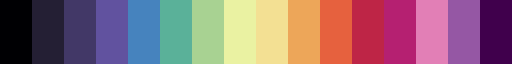

In [2]:
# Load colormap

# Read the colormap from a .txt file
def load_colormap_from_txt(file_path):
    # Load RGB values from the file
    rgb_values = np.loadtxt(file_path)
    return ListedColormap(rgb_values)

# Example usage
colormap_file = 'chase-spectral-rgb.txt'  # Replace with your .txt file path
radar_cmap = load_colormap_from_txt(colormap_file)

discrete_cmap = ListedColormap(radar_cmap(np.linspace(0, 1, 16)))
discrete_mask_cmap = discrete_cmap.copy()
discrete_mask_cmap.set_under(color='white') #set values below vmin to white
discrete_mask_cmap.set_bad(color='gray') #set missing (NaN) values to gray

discrete_mask_cmap

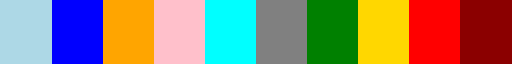

In [3]:
hid_cmap = colors.ListedColormap(['lightblue','blue','orange','pink','cyan','gray','green','gold','red','darkred'])
hid_cmap.set_under(color='white') #set values below vmin to white
hid_cmap.set_bad(color='white') #set missing (NaN) values to white

hid_cmap

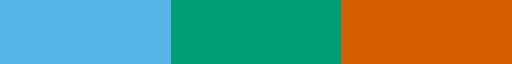

In [4]:
# Define color-blind safe colors
cb_orange = [230/255, 159/255, 0]
cb_skyblue = [86/255, 180/255, 233/255]
cb_green = [0, 158/255, 115/255]
cb_yellow = [240/255, 228/255, 66/255]
cb_blue = [0, 114/255, 178/255]
cb_red = [213/255, 94/255, 0]
cb_purple = [204/255, 121/255, 167/255]

ecco_cmap = colors.ListedColormap([cb_skyblue, cb_green, cb_red])
ecco_cmap.set_under(color='white') #set values below vmin to white
ecco_cmap.set_bad(color='white') #set missing (NaN) values to

ecco_cmap

Open volume data

In [5]:
#seapol_vol = xr.open_dataset('/huracan/tank4/cornell/ORCESTRA/sea-pol/qc_data/level4v1.2/PICCOLO_level4_volume_3D.nc')
seapol_vol = xr.open_dataset("ipfs://bafybeifryiuhi64d6vjod6mkrfaa3rxtjrfjlv7lmvjznagzpb3q6bfyea", engine="zarr")

Open low-level rain rate data

In [6]:
#seapol_ll = xr.open_dataset('/huracan/tank4/cornell/ORCESTRA/sea-pol/qc_data/level4v1.2/PICCOLO_level4_rainrate_2D.nc')
seapol_ll = xr.open_dataset("ipfs://bafybeigv34pwsk3t5wlmatncnavfsfie5zyd6j36eyv57qsh6f7usn5kg4", engine="zarr")

In [7]:
# change -9999 missing data to zeros for low-level rain rate (takes ~15 min)
ll_rainrate = seapol_ll.RAINRATE.where(seapol_ll.RAINRATE != -9999., 0)

In [8]:
# mask out data with unrealistically high rain rates (greater than 300 mm/h)
ll_rainrate_masked = ll_rainrate.where((ll_rainrate <= 300) | (ll_rainrate.isnull()),0)

In [9]:
# restrict low-level rain rate to volume xy grid
rainrate = ll_rainrate_masked.sel(X=slice(seapol_vol.X.min(), seapol_vol.X.max()), Y=slice(seapol_vol.Y.min(), seapol_vol.Y.max()))

Open conv/strat data

In [10]:
convstrat = xr.open_dataset('/huracan/tank4/cornell/ORCESTRA/sea-pol/qc_data/level4v1.2/PICCOLO_Sea-Pol_level4_convstrat_3D_10dbz.nc')

Read in histogram counts/density over entire campaign (AP)

In [11]:
vol_HID_all = xr.open_dataset('./processed_data/SEA-POLv1.2_vol_HID_hist_density.nc')
vol_HID_all

<xarray.Dataset> Size: 626kB
Dimensions:        (time: 3724, hid_bins: 10, hid_bin_edges: 11)
Coordinates:
  * time           (time) datetime64[ns] 30kB 2024-08-28T20:20:00 ... 2024-09...
  * hid_bins       (hid_bins) float64 80B 0.5 1.5 2.5 3.5 ... 6.5 7.5 8.5 9.5
  * hid_bin_edges  (hid_bin_edges) float64 88B 0.5 1.5 2.5 3.5 ... 8.5 9.5 10.5
Data variables:
    hid_hist       (time, hid_bins) float64 298kB ...
    hid_density    (time, hid_bins) float64 298kB ...
    bin_edges      (hid_bin_edges) float64 88B ...

 Put on regular 10-minute time series

In [12]:
#make regular 10-minute time series
#start_time = np.datetime64('2024-08-16T08:00:00') #campaign start
start_time = np.datetime64('2024-08-28T20:20:00') #AP start
#start_time = np.datetime64('2024-09-04T00:00:00') #for testing
end_time = np.datetime64('2024-09-23T16:50:00') #campaign end
#end_time = np.datetime64('2024-09-05T00:00:00') #for testing
time10m = pd.date_range(start_time, end_time, freq='10 min')
time10m = pd.to_datetime(time10m)

# re-index to 10 min grid, pad with nans
cs_10m = convstrat.EchoTypeComp.reindex(time=time10m)
rainrate_10m = rainrate.reindex(time=time10m)

In [13]:
# mask out data beyond 120 km
# use x and y to calculate a grid and get each grid point's distance from array center
X, Y = np.meshgrid(convstrat.x0.values, convstrat.y0.values)
center_x = np.nanmean(X)
center_y = np.nanmean(Y)
distance_from_center = np.sqrt((X - center_x)**2 + (Y - center_y)**2)

# mask out anything past 120 km (120000 meters)
outer_mask = distance_from_center > 120000
cs_10m = cs_10m.where(~outer_mask,np.nan)
rainrate_10m = rainrate_10m.where(~outer_mask,np.nan)


In [28]:
#Calculate global fraction [all echoes, all scenes]
strat_frac_glob = np.sum((cs_10m >= 10) & (cs_10m < 20))/np.sum(cs_10m > 0)
mixed_frac_glob = np.sum((cs_10m >= 20) & (cs_10m < 30))/np.sum(cs_10m > 0)
conv_frac_glob = np.sum((cs_10m >= 30) & (cs_10m < 40))/np.sum(cs_10m > 0)

print('strat_frac_glob:', strat_frac_glob.values)
print('mixed_frac_glob:', mixed_frac_glob.values)
print('conv_frac_glob:', conv_frac_glob.values)

strat_frac_glob: 0.504678270706035
mixed_frac_glob: 0.2947443831446569
conv_frac_glob: 0.2005773461493081


In [14]:
#Calculate fractions for each time step

#pre-allocate nan arrays to store fractions for each time step
strat_frac = np.full(len(time10m), np.nan)
mixed_frac = np.full(len(time10m), np.nan)
conv_frac = np.full(len(time10m), np.nan)

strat_rain_frac = np.full(len(time10m), np.nan)
mixed_rain_frac = np.full(len(time10m), np.nan)
conv_rain_frac = np.full(len(time10m), np.nan)

#for t in range(len(convstrat.time)):
for t in range(0,len(time10m)):
    #cs_map = convstrat.EchoTypeComp.isel(time=t).values
    cs_map = cs_10m.sel(time=time10m[t])[0,:,:].values
    rain_map = rainrate_10m.sel(time=time10m[t]).values
    
    #if np.sum(cs_map > 0)/cs_map.size < 0.01: #if no valid echoes, skip to next time step
    #    continue
    
    #rain area fractions
    strat_frac[t] = np.sum((cs_map >= 10) & (cs_map < 20))/np.sum(cs_map > 0)
    mixed_frac[t] = np.sum((cs_map >= 20) & (cs_map < 30))/np.sum(cs_map > 0)
    conv_frac[t] = np.sum((cs_map >= 30) & (cs_map < 40))/np.sum(cs_map > 0)
    
    #rain fractions (fraction of total low-level rain rate (over classified echoes) that falls within each echo type)
    strat_rain_frac[t] = np.nansum(rain_map[(cs_map >= 10) & (cs_map < 20)]) / np.nansum(rain_map[cs_map > 0])
    mixed_rain_frac[t] = np.nansum(rain_map[(cs_map >= 20) & (cs_map < 30)]) / np.nansum(rain_map[cs_map > 0])
    conv_rain_frac[t] = np.nansum(rain_map[(cs_map >= 30) & (cs_map < 40)]) / np.nansum(rain_map[cs_map > 0])

/tmp/ipykernel_476140/3120705502.py:27: RuntimeWarning: invalid value encountered in scalar divide
  strat_rain_frac[t] = np.nansum(rain_map[(cs_map >= 10) & (cs_map < 20)]) / np.nansum(rain_map[cs_map > 0])
/tmp/ipykernel_476140/3120705502.py:28: RuntimeWarning: invalid value encountered in scalar divide
  mixed_rain_frac[t] = np.nansum(rain_map[(cs_map >= 20) & (cs_map < 30)]) / np.nansum(rain_map[cs_map > 0])
/tmp/ipykernel_476140/3120705502.py:29: RuntimeWarning: invalid value encountered in scalar divide
  conv_rain_frac[t] = np.nansum(rain_map[(cs_map >= 30) & (cs_map < 40)]) / np.nansum(rain_map[cs_map > 0])
/tmp/ipykernel_476140/3120705502.py:22: RuntimeWarning: invalid value encountered in scalar divide
  strat_frac[t] = np.sum((cs_map >= 10) & (cs_map < 20))/np.sum(cs_map > 0)
/tmp/ipykernel_476140/3120705502.py:23: RuntimeWarning: invalid value encountered in scalar divide
  mixed_frac[t] = np.sum((cs_map >= 20) & (cs_map < 30))/np.sum(cs_map > 0)
/tmp/ipykernel_476140/31207

In [31]:
print('avg strat area frac:', np.nanmean(strat_frac))
print('avg mixed area frac:', np.nanmean(mixed_frac))
print('avg conv area frac:', np.nanmean(conv_frac))
print('total:', np.nanmean(strat_frac) + np.nanmean(mixed_frac) + np.nanmean(conv_frac))
print('strat+mixed area frac:', np.nanmean(strat_frac) + np.nanmean(mixed_frac))

print('avg strat rain frac:', np.nanmean(strat_rain_frac))
print('avg mixed rain frac:', np.nanmean(mixed_rain_frac))
print('avg conv rain frac:', np.nanmean(conv_rain_frac))
print('total:', np.nanmean(strat_rain_frac) + np.nanmean(mixed_rain_frac) + np.nanmean(conv_rain_frac))

avg strat area frac: 0.4371578846507131
avg mixed area frac: 0.27366487663395167
avg conv area frac: 0.28917723871533524
total: 1.0
strat+mixed area frac: 0.7108227612846647
avg strat rain frac: 0.19961973397676464
avg mixed rain frac: 0.25516191263066196
avg conv rain frac: 0.545218353518615
total: 1.0000000001260416


In [32]:
# take average over E (before 9/13) and W (after 9/13)
timeEW = np.datetime64('2024-09-13T02:38:00')
iEW = np.abs(time10m - timeEW).argmin()

strat_frac_E = np.nanmean(strat_frac[:iEW])
mixed_frac_E = np.nanmean(mixed_frac[:iEW])
conv_frac_E = np.nanmean(conv_frac[:iEW])
strat_frac_W = np.nanmean(strat_frac[iEW:])
mixed_frac_W = np.nanmean(mixed_frac[iEW:])
conv_frac_W = np.nanmean(conv_frac[iEW:])
print('E strat area frac:', strat_frac_E)
print('E mixed area frac:', mixed_frac_E)
print('E conv area frac:', conv_frac_E)
print('W strat area frac:', strat_frac_W)
print('W mixed area frac:', mixed_frac_W)
print('W conv area frac:', conv_frac_W)

strat_rain_frac_E = np.nanmean(strat_rain_frac[:iEW])
mixed_rain_frac_E = np.nanmean(mixed_rain_frac[:iEW])
conv_rain_frac_E = np.nanmean(conv_rain_frac[:iEW])
strat_rain_frac_W = np.nanmean(strat_rain_frac[iEW:])
mixed_rain_frac_W = np.nanmean(mixed_rain_frac[iEW:])
conv_rain_frac_W = np.nanmean(conv_rain_frac[iEW:])
print('E strat rain frac:', strat_rain_frac_E)
print('E mixed rain frac:', mixed_rain_frac_E)
print('E conv rain frac:', conv_rain_frac_E)
print('W strat rain frac:', strat_rain_frac_W)
print('W mixed rain frac:', mixed_rain_frac_W)
print('W conv rain frac:', conv_rain_frac_W)


E strat area frac: 0.4801907374567916
E mixed area frac: 0.2898256610408097
E conv area frac: 0.2299836015023987
W strat area frac: 0.30779251492189963
W mixed area frac: 0.22508232368720568
W conv area frac: 0.4671251613908946
E strat rain frac: 0.2264788738111783
E mixed rain frac: 0.28143270794160424
E conv rain frac: 0.4920884182695167
W strat rain frac: 0.11468123159687588
W mixed rain frac: 0.1720839725403754
W conv rain frac: 0.7132347963168619


In [15]:
# HID categories
#hid_labels = ['DZ', 'RN', 'CR', 'AG', 'WS', 'VI', 'LDG', 'HDG', 'HA', 'BD']
#hid_colors = ['lightblue', 'blue', 'orange', 'pink', 'cyan', 'gray', 'green', 'gold', 'red', 'darkred']

drizzle_frac = vol_HID_all.hid_density[:,0]*np.diff(vol_HID_all.bin_edges)[0]
rain_frac = vol_HID_all.hid_density[:,1]*np.diff(vol_HID_all.bin_edges)[1]
cr_frac = vol_HID_all.hid_density[:,2]*np.diff(vol_HID_all.bin_edges)[2] 
aggr_frac = vol_HID_all.hid_density[:,3]*np.diff(vol_HID_all.bin_edges)[3]
wsnow_frac = vol_HID_all.hid_density[:,4]*np.diff(vol_HID_all.bin_edges)[4]
vice_frac = vol_HID_all.hid_density[:,5]*np.diff(vol_HID_all.bin_edges)[5]
ldg_frac = vol_HID_all.hid_density[:,6]*np.diff(vol_HID_all.bin_edges)[6]
hdg_frac = vol_HID_all.hid_density[:,7]*np.diff(vol_HID_all.bin_edges)[7]
hail_frac = vol_HID_all.hid_density[:,8]*np.diff(vol_HID_all.bin_edges)[8]
bigdrop_frac = vol_HID_all.hid_density[:,9]*np.diff(vol_HID_all.bin_edges)[9]


## main plot

Plotting ECCO rain category Stratiform with color dodgerblue
Plotting ECCO rain category Mixed with color mediumseagreen
Plotting ECCO rain category Convective with color firebrick
Plotting ECCO category Stratiform with color dodgerblue
Plotting ECCO category Mixed with color mediumseagreen
Plotting ECCO category Convective with color firebrick
Plotting HID category DZ with color lightblue
Plotting HID category RN with color blue
Plotting HID category CR with color orange
Plotting HID category AG with color pink
Plotting HID category WS with color cyan
Plotting HID category VI with color gray
Plotting HID category LDG with color green
Plotting HID category HDG with color gold
Plotting HID category HA with color red
Plotting HID category BD with color darkred


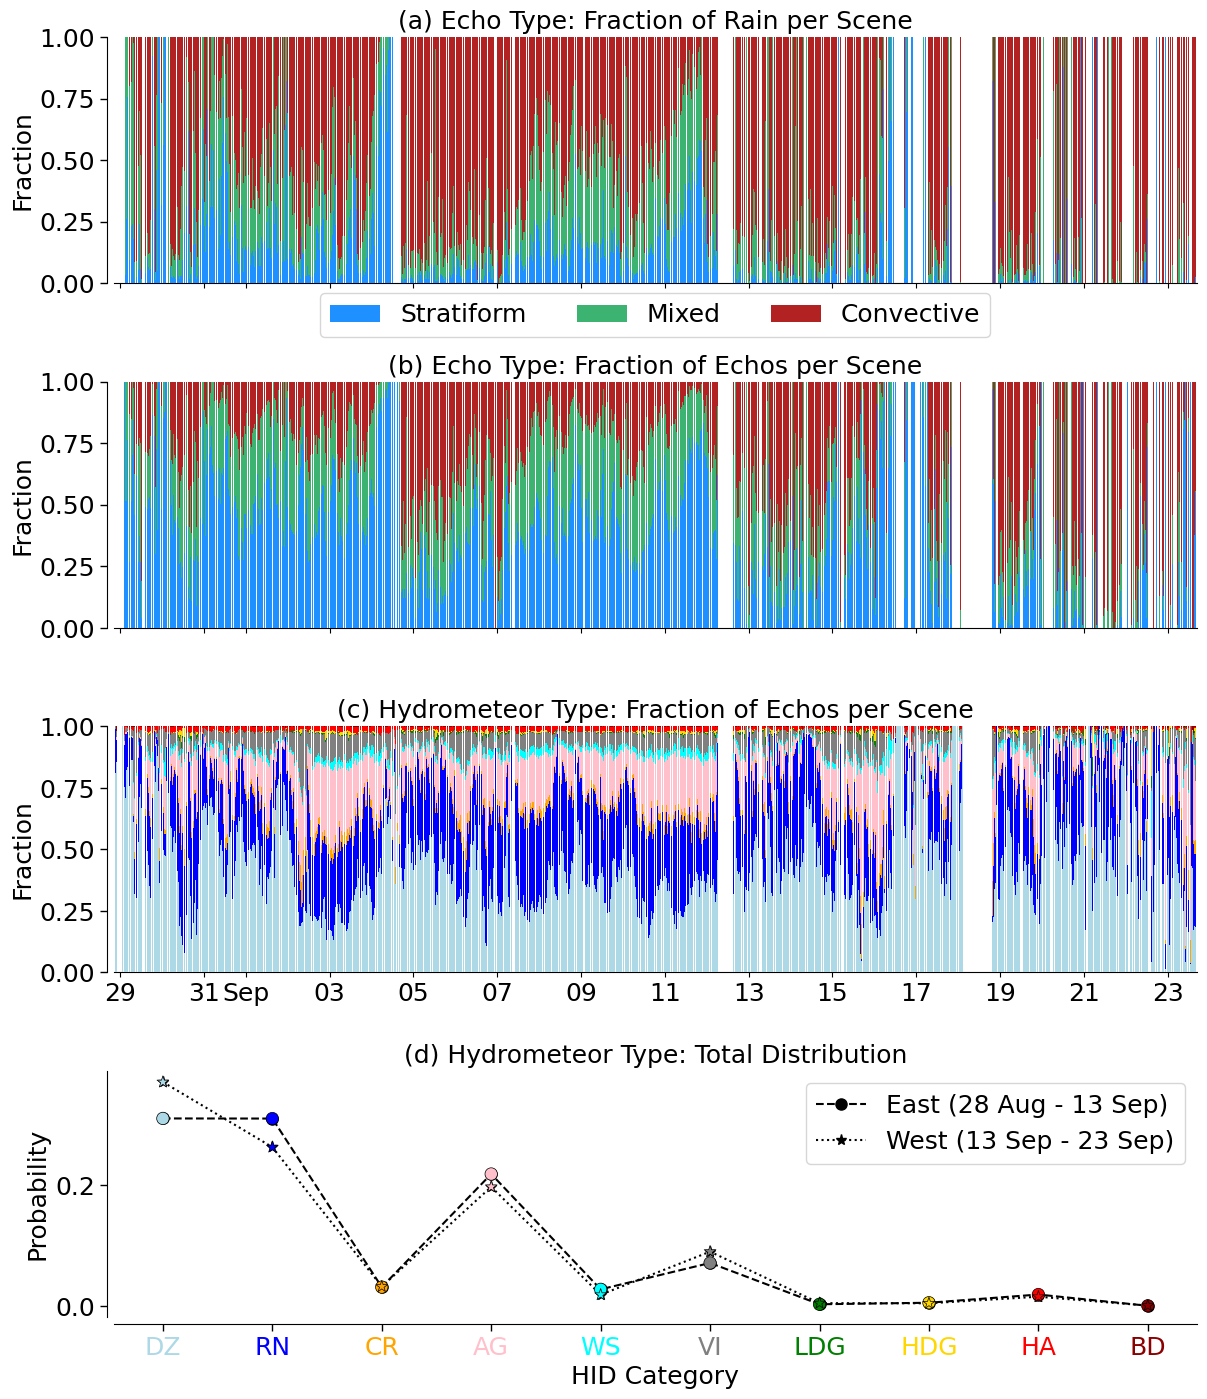

In [16]:
fig, axs = plt.subplots(4, 1, figsize=(12, 16))

ecco_labels = ['Stratiform', 'Mixed', 'Convective']
ecco_colors = ['dodgerblue','mediumseagreen','firebrick']

###################################################################################
# plot time series of conv/strat rain fraction as stacked bar chart

# Prepare data
ecco_data = np.array([strat_rain_frac, mixed_rain_frac, conv_rain_frac])
x_pos = np.arange(len(time10m))

# Create stacked bar chart
bottom = np.zeros(len(time10m))
for i, (label, color) in enumerate(zip(ecco_labels, ecco_colors)):
    print(f'Plotting ECCO rain category {label} with color {color}')
    axs[0].bar(x_pos, ecco_data[i], label=label, color=color, bottom=bottom)
    bottom += ecco_data[i]
    
axs[0].set_ylim(0,1)
    
# Primary axis stays in index space (x_pos)
axs[0].set_xlim(x_pos.min() - 0.5, x_pos.max() + 0.5)
axs[0].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
axs[0].xaxis.set_visible(False)
axs[0].spines['bottom'].set_visible(False)

# Secondary x-axis in date space so we can use AutoDateLocator/ConciseDateFormatter
_time_dt = pd.to_datetime(time10m)
_time_num = mdates.date2num(_time_dt.to_pydatetime())

def _x_to_date(x):
    return np.interp(x, x_pos, _time_num)

def _date_to_x(d):
    return np.interp(d, _time_num, x_pos)

secax = axs[0].secondary_xaxis('bottom', functions=(_x_to_date, _date_to_x))
_locator = mdates.AutoDateLocator(minticks=10, maxticks=20)
secax.xaxis.set_major_locator(_locator)
_formatter = mdates.ConciseDateFormatter(_locator)
_formatter.show_offset = False
secax.xaxis.set_major_formatter(_formatter)
secax.xaxis.get_offset_text().set_visible(False)
secax.tick_params(axis='x', which='both',labelbottom=False)
#secax.spines['bottom'].set_visible(False)
#for t in secax.get_xticklabels():
#    t.set_rotation(45)
#    t.set_ha('right')

# Legend on the bottom, outside the plot
axs[0].legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=10,
    borderaxespad=0.0,
    fontsize = 18,
)

axs[0].tick_params(axis='y', labelsize=18)
axs[0].set_ylabel('Fraction', fontsize=18)
axs[0].set_title('(a) Echo Type: Fraction of Rain per Scene',fontsize = 18)

###################################################################################
# plot time series of conv/strat area fraction as stacked bar chart

# Prepare data
ecco_data = np.array([strat_frac, mixed_frac, conv_frac])
x_pos = np.arange(len(time10m))

# Create stacked bar chart
bottom = np.zeros(len(time10m))
for i, (label, color) in enumerate(zip(ecco_labels, ecco_colors)):
    print(f'Plotting ECCO category {label} with color {color}')
    axs[1].bar(x_pos, ecco_data[i], label=label, color=color, bottom=bottom)
    bottom += ecco_data[i]
    
axs[1].set_ylim(0,1)

# Primary axis stays in index space (x_pos)
axs[1].set_xlim(x_pos.min() - 0.5, x_pos.max() + 0.5)
axs[1].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
axs[1].xaxis.set_visible(False)
axs[1].spines['bottom'].set_visible(False)

# Secondary x-axis in date space so we can use AutoDateLocator/ConciseDateFormatter
_time_dt = pd.to_datetime(time10m)
_time_num = mdates.date2num(_time_dt.to_pydatetime())

def _x_to_date(x):
    return np.interp(x, x_pos, _time_num)

def _date_to_x(d):
    return np.interp(d, _time_num, x_pos)

secax = axs[1].secondary_xaxis('bottom', functions=(_x_to_date, _date_to_x))
_locator = mdates.AutoDateLocator(minticks=10, maxticks=20)
secax.xaxis.set_major_locator(_locator)
_formatter = mdates.ConciseDateFormatter(_locator)
_formatter.show_offset = False
secax.xaxis.set_major_formatter(_formatter)
secax.xaxis.get_offset_text().set_visible(False)
secax.tick_params(axis='x', which='both',labelbottom=False)
#secax.spines['bottom'].set_visible(False)
#for t in secax.get_xticklabels():
#    t.set_rotation(45)
#    t.set_ha('right')

# Legend on the bottom, outside the plot
#axs[1].legend(
#    loc='upper center',
#    bbox_to_anchor=(0.5, -0.04),
#    ncol=10,
#    borderaxespad=0.0,
#    fontsize = 18,
#)

axs[1].tick_params(axis='y', labelsize=18)
axs[1].set_ylabel('Fraction', fontsize=18)
axs[1].set_title('(b) Echo Type: Fraction of Echos per Scene',fontsize = 18)

###################################################################################
# plot time series of probability of individual HID types as stacked bar chart
hid_labels = ['DZ', 'RN', 'CR', 'AG', 'WS', 'VI', 'LDG', 'HDG', 'HA', 'BD']
hid_colors = ['lightblue', 'blue', 'orange', 'pink', 'cyan', 'gray', 'green', 'gold', 'red', 'darkred']

# Prepare data
hid_data = np.array([vol_HID_all.hid_density[:, i] * np.diff(vol_HID_all.bin_edges)[i] for i in range(10)])
x_pos = np.arange(len(vol_HID_all.time))

# Create stacked bar chart
bottom = np.zeros(len(vol_HID_all.time))
for i, (label, color) in enumerate(zip(hid_labels, hid_colors)):
    print(f'Plotting HID category {label} with color {color}')
    axs[2].bar(x_pos, hid_data[i], label=label, color=color, bottom=bottom)
    bottom += hid_data[i]
    
axs[2].set_ylim(0,1)

# Primary axis stays in index space (x_pos)
axs[2].set_xlim(x_pos.min() - 0.5, x_pos.max() + 0.5)
axs[2].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
axs[2].xaxis.set_visible(False)
axs[2].spines['bottom'].set_visible(False)

# Secondary x-axis in date space so we can use AutoDateLocator/ConciseDateFormatter
_time_dt = pd.to_datetime(vol_HID_all.time.values)
_time_num = mdates.date2num(_time_dt.to_pydatetime())

def _x_to_date(x):
    return np.interp(x, x_pos, _time_num)

def _date_to_x(d):
    return np.interp(d, _time_num, x_pos)

secax = axs[2].secondary_xaxis('bottom', functions=(_x_to_date, _date_to_x))
_locator = mdates.AutoDateLocator(minticks=10, maxticks=20)
secax.xaxis.set_major_locator(_locator)
_formatter = mdates.ConciseDateFormatter(_locator)
_formatter.show_offset = False
secax.xaxis.set_major_formatter(_formatter)
secax.xaxis.get_offset_text().set_visible(False)
secax.tick_params(axis='x', labelsize=18)
#secax.spines['bottom'].set_visible(False)
#for t in secax.get_xticklabels():
#    t.set_rotation(45)
#    t.set_ha('right')

axs[2].tick_params(axis='y', labelsize=18)
axs[2].set_ylabel('Fraction', fontsize=18)

# Legend on the bottom, outside the plot
#axs[2].legend(
#    loc='upper center',
#    bbox_to_anchor=(0.5, -0.15),
#    ncol=10,
#    borderaxespad=0.0,
#)

axs[2].set_title('(c) Hydrometeor Type: Fraction of Echos per Scene',fontsize = 18)

##############################################################################
# Probability density in each bin across all times
total_hid_hist = np.nansum(vol_HID_all.hid_hist.values, axis=0)
total_count = np.nansum(np.nansum(vol_HID_all.hid_hist.values,axis=0),axis=0)
total_hid_prob = (total_hid_hist/total_count)*np.diff(vol_HID_all.bin_edges)

#find index corresponding to 9/13
iEW = np.abs(pd.to_datetime(vol_HID_all.time) - np.datetime64('2024-09-13')).argmin()

# just over east (before 9/13)
east_hid_hist = np.nansum(vol_HID_all.hid_hist.values[:iEW,:], axis=0)
east_count = np.nansum(np.nansum(vol_HID_all.hid_hist.values[:iEW,:],axis=0),axis=0)
east_hid_prob = (east_hid_hist/east_count)*np.diff(vol_HID_all.bin_edges)

# just over west (after 9/13)
west_hid_hist = np.nansum(vol_HID_all.hid_hist.values[iEW:,:], axis=0)
west_count = np.nansum(np.nansum(vol_HID_all.hid_hist.values[iEW:,:],axis=0),axis=0)
west_hid_prob = (west_hid_hist/west_count)*np.diff(vol_HID_all.bin_edges)

# Plot: use a line + a colored scatter overlay so each marker can have its own color
_x = vol_HID_all.bin_edges[:-1]
axs[3].plot(_x, east_hid_prob, 'o--', markersize=8, color='black', linewidth=1.5, label='East (28 Aug - 13 Sep)',zorder=1)
axs[3].plot(_x, west_hid_prob, '*:', markersize=8, color='black', linewidth=1.5, label='West (13 Sep - 23 Sep)',zorder=2)

axs[3].scatter(
    _x,
    east_hid_prob,
    marker='o',
    s=80,
    c=hid_colors,
    edgecolors='black',
    linewidths=0.5,
    zorder=3
)
axs[3].scatter(
    _x,
    west_hid_prob,
    marker='*',
    s=80,
    c=hid_colors,
    edgecolors='black',
    linewidths=0.5,
    zorder=4
)
axs[3].set_xlabel('HID Category',fontsize=18)
axs[3].set_ylabel('Probability',fontsize=18)
axs[3].set_title('(d) Hydrometeor Type: Total Distribution',fontsize=18)
axs[3].tick_params(axis='both',labelsize=18)
axs[3].set_xticks(_x)
axs[3].set_xticklabels(hid_labels, fontsize=18)
axs[3].legend(fontsize=18)

sns.set_context('paper') 
sns.despine(offset=5)

# Layout first, then draw, then apply per-label tick colors
fig.tight_layout(rect=[0, 0.12, 1, 1])
fig.subplots_adjust(hspace=0.4)

# Ensure per-label tick colors stick (Matplotlib/Seaborn can recreate tick labels during draw)
fig.canvas.draw()
for _t, _c in zip(axs[3].get_xticklabels(), hid_colors):
    _t.set_color(_c)
    
axs[0].spines['bottom'].set_visible(False)    
axs[1].spines['bottom'].set_visible(False)
axs[2].spines['bottom'].set_visible(False)

#save figures
fig.savefig('./figures/Fig_HID_convstrat.pdf', dpi=300, bbox_inches='tight')